# Évaluation et comparaison des modèles

Définir les métriques d'évaluation, créer un tableau comparatif des trois modèles et identifier le meilleur baseline sur chaque dataset.

## Définition des métriques

Une métrique est un chiffre qui mesure la performance d'un modèle. Les labels étant disponibles sur les trois datasets, on peut calculer des métriques supervisées :

- Précision: parmi toutes les anomalies détectées, quelle proportion est réellement anormale.
- Recall : parmi toutes les vraies anomalies, quelle proportion a été détectée.
- f1-score : moyenne harmonique de la précision et du rappel. C'est la métrique principale car elle pénalise les modèles qui sacrifient l'un pour l'autre.
- AUC-ROC: aire sous la courbe ROC donc elle mesure la capacité du modèle à séparer les classes à différents seuils de décision. Une valeur de 0.5 correspond à un modèle aléatoire, 1.0 à un modèle parfait.

## Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report)
from sklearn.model_selection import train_test_split



In [2]:
chemin_CICIDS = '../Data/cicids_clean.csv'
chemin_UNSW   = '../Data/unsw_clean.csv'
chemin_LOGS   = '../Data/logs_clean.csv'

df_cicids = pd.read_csv(chemin_CICIDS, low_memory=False)
df_unsw   = pd.read_csv(chemin_UNSW,low_memory=False)
df_logs   = pd.read_csv(chemin_LOGS,low_memory=False)


## Fonction utilitaire

On définit une fonction qui entraîne les trois modèles, calcule toutes les métriques et retourne les résultats sous forme de dictionnaire.

In [3]:
def evaluer_modeles(X, y, contamination, dataset_name):
    
    resultats = []  # liste  vice qui stockera les résultats de chaque modèle

    # les 3 modèles avec le même taux de contamination
    modeles = {'LOF' : LocalOutlierFactor(n_neighbors=20, contamination=contamination),'One-Class SVM': OneClassSVM(kernel='rbf', nu=contamination, gamma='scale'),'Isolation Forest' : IsolationForest(contamination=contamination, random_state=42, n_jobs=-1)}

    for nom, modele in modeles.items():
        t0 = time.time()
        pred = (modele.fit_predict(X) == -1).astype(int)  # conversion -1 pour anomalie en 1 et sinon en 0
        temps = round(time.time() - t0, 2)  # temps d'entraînement en s

        # chaque modèle a sa propre façon de fournir un score continu pour l'AUC-ROC 
        # donc hasattr permet de détecter quel modèle on utilise en vérifiant si l'attribut existe
        # si le modèle a negative_outlier_factor_ c'est forcément le LOF, si il a score_samples c'est l'Isolation Forest, sinon c'est le SVM.
        if hasattr(modele, 'negative_outlier_factor_'):  # LOF
            score = -modele.negative_outlier_factor_ # on met un moins pour avoir un score positif
        elif hasattr(modele, 'score_samples'):           # Isolation Forest
            score = -modele.score_samples(X)
        else:                                            # One-Class SVM
            score = -modele.decision_function(X)

        # on calcule et stocke toutes les métriques pour ce modèle
        resultats.append({
            'Dataset' : dataset_name,
            'Modèle': nom,
            'Temps (s)' : temps,
            'Précision' : round(precision_score(y, pred, zero_division=0), 2),
            'Recall' : round(recall_score(y, pred, zero_division=0), 2),
            'F1-score': round(f1_score(y, pred, zero_division=0), 2),
            'AUC-ROC' : round(roc_auc_score(y, score), 2)})

    return resultats  


## Dataset 1 : CIC-IDS-2017

### Préparation

In [4]:
from sklearn.model_selection import train_test_split  # pour créer un échantillon avec la même proportion

X = df_cicids.drop(columns=['Label']).select_dtypes(include=[np.number])  # on garde uniquement les colonnes numériques sans le label
y = (df_cicids['Label'] != 'BENIGN').astype(int)  # 0 pour normal et  1 pour attaque
X = X.fillna(0).replace([np.inf, -np.inf], 0)  # on remplace les valeurs manquantes et infinies par 0
X_scaled = StandardScaler().fit_transform(X)  # normalisation donc met toutes les features à la même échelle
X_cicids_sample, _, y_cicids_sample, _ = train_test_split(X_scaled, y, train_size=10000, stratify=y, random_state=42) # on garde 10 000 points en respectant les proportions des classes (stratify=y)

print(f"Taille échantillon : {X_cicids_sample.shape}")       
print(f"Proportion d'attaques : {y_cicids_sample.mean():.2%}") 

Taille échantillon : (10000, 79)
Proportion d'attaques : 57.38%


### Évaluation 


In [6]:
resultats_cicids = evaluer_modeles(X_cicids_sample, y_cicids_sample, 0.50, 'CICIDS2017')
print(resultats_cicids)

[{'Dataset': 'CICIDS2017', 'Modèle': 'LOF', 'Temps (s)': 0.77, 'Précision': 0.55, 'Recall': 0.48, 'F1-score': 0.51, 'AUC-ROC': 0.45}, {'Dataset': 'CICIDS2017', 'Modèle': 'One-Class SVM', 'Temps (s)': 27.4, 'Précision': 0.38, 'Recall': 0.33, 'F1-score': 0.36, 'AUC-ROC': 0.25}, {'Dataset': 'CICIDS2017', 'Modèle': 'Isolation Forest', 'Temps (s)': 0.42, 'Précision': 0.45, 'Recall': 0.4, 'F1-score': 0.42, 'AUC-ROC': 0.33}]


## Dataset 2 : UNSW-NB15

### Préparation

In [7]:
# préparation features / label
X = df_unsw.drop(columns=['Label']).select_dtypes(include=[np.number])
y_unsw = df_unsw['Label']  # 0 pour normal et 1 pour attaque
X = X.fillna(0).replace([np.inf, -np.inf], 0)  # remplace valeurs manquantes et infinies par 0
X_unsw_scaled = StandardScaler().fit_transform(X)  # normalisation

# échantillon stratifié de 10 000 points
X_unsw_sample, _, y_unsw_sample, _ = train_test_split(X_unsw_scaled, y_unsw, train_size=10000, stratify=y_unsw, random_state=42)

print(f"Taille échantillon : {X_unsw_sample.shape}")
print(f"Proportion d'attaques : {y_unsw_sample.mean():.2%}")

Taille échantillon : (10000, 44)
Proportion d'attaques : 3.17%


### Evaluation

In [12]:
resultats_unsw = evaluer_modeles(X_unsw_sample, y_unsw_sample, 0.03, 'UNSW-NB15')
print(resultats_unsw)

[{'Dataset': 'UNSW-NB15', 'Modèle': 'LOF', 'Temps (s)': 0.64, 'Précision': 0.18, 'Recall': 0.17, 'F1-score': 0.18, 'AUC-ROC': 0.56}, {'Dataset': 'UNSW-NB15', 'Modèle': 'One-Class SVM', 'Temps (s)': 2.57, 'Précision': 0.25, 'Recall': 0.24, 'F1-score': 0.25, 'AUC-ROC': 0.87}, {'Dataset': 'UNSW-NB15', 'Modèle': 'Isolation Forest', 'Temps (s)': 0.94, 'Précision': 0.34, 'Recall': 0.32, 'F1-score': 0.33, 'AUC-ROC': 0.96}]



## Dataset 3 : Cybersecurity Threat Detection Logs

### Préparation

In [10]:
# encodage des colonnes texte en nombres
df_enc = df_logs.copy()
for col in ['protocol', 'action', 'log_type']:
    if col in df_enc.columns:
        df_enc[col + '_enc'] = LabelEncoder().fit_transform(df_enc[col].astype(str))

# sélection des features et normalisation
features = ['bytes_transferred'] + [c for c in df_enc.columns if c.endswith('_enc')]
X = df_enc[features].fillna(0)
y = (df_logs['threat_label'] != 'benign').astype(int)  # 0 pour normal et 1 pour anomalie
X_logs_scaled = StandardScaler().fit_transform(X)


X_logs_sample, _, y_logs_sample, _ = train_test_split( X_logs_scaled, y, train_size=10000, stratify=y, random_state=42) # echantillon stratifié de 10 000 points

print(f"Taille échantillon : {X_logs_sample.shape}")
print(f"Proportion d'anomalies : {y_logs_sample.mean():.2%}")

Taille échantillon : (10000, 4)
Proportion d'anomalies : 8.04%


### Evaluation

In [13]:
resultats_logs = evaluer_modeles(X_logs_sample, y_logs_sample, 0.08, 'Logs')
print(resultats_logs)

[{'Dataset': 'Logs', 'Modèle': 'LOF', 'Temps (s)': 0.19, 'Précision': 0.12, 'Recall': 0.12, 'F1-score': 0.12, 'AUC-ROC': 0.51}, {'Dataset': 'Logs', 'Modèle': 'One-Class SVM', 'Temps (s)': 3.34, 'Précision': 0.08, 'Recall': 0.08, 'F1-score': 0.08, 'AUC-ROC': 0.46}, {'Dataset': 'Logs', 'Modèle': 'Isolation Forest', 'Temps (s)': 0.73, 'Précision': 0.1, 'Recall': 0.1, 'F1-score': 0.1, 'AUC-ROC': 0.54}]



## Tableau comparatif des 3 modèles

In [15]:
df_resultats = pd.DataFrame(resultats_cicids + resultats_unsw + resultats_logs) #  tous les résultats
print(df_resultats.to_string(index=False))


   Dataset           Modèle  Temps (s)  Précision  Recall  F1-score  AUC-ROC
CICIDS2017              LOF       0.77       0.55    0.48      0.51     0.45
CICIDS2017    One-Class SVM      27.40       0.38    0.33      0.36     0.25
CICIDS2017 Isolation Forest       0.42       0.45    0.40      0.42     0.33
 UNSW-NB15              LOF       0.64       0.18    0.17      0.18     0.56
 UNSW-NB15    One-Class SVM       2.57       0.25    0.24      0.25     0.87
 UNSW-NB15 Isolation Forest       0.94       0.34    0.32      0.33     0.96
      Logs              LOF       0.19       0.12    0.12      0.12     0.51
      Logs    One-Class SVM       3.34       0.08    0.08      0.08     0.46
      Logs Isolation Forest       0.73       0.10    0.10      0.10     0.54


Sur le dataset CICIDS2017, l'algorithme LOF est le meilleur avec un f1 de 0.51 et un temps de seulement 0.77s. Cependant son AUC-ROC de 0.45 est inférieur à 0.5, ce qui signifie qu'il fait pire qu'un modèle aléatoire en termes de séparation des classes et le f1 correct s'explique uniquement par le fait que les attaques sont majoritaires dans ce dataset.
Sur le dataset UNSW-NB15, l'Isolation Forest domine clairement avec le meilleur f1 (0.33) et surtout le meilleur AUC-ROC (0.96). Le One-Class SVM obtient aussi un bon AUC de 0.87 mais est plus lent. Le LOF est décevant avec un AUC de seulement 0.56.
Sur Logs, les trois modèles sont proches et tous plutôt mauvais avec un f1 entre 0.08 et 0.12 et AUC entre 0.46 et 0.54, soit à peine mieux qu'un modèle aléatoire. Aucun algorithme ne fonctionne sur ce dataset.
En conclusion, l'Isolation Forest s'impose comme le meilleur baseline global à la fois rapide, performant sur UNSW et compétitif sur les autres datasets.


## Visualisation comparative

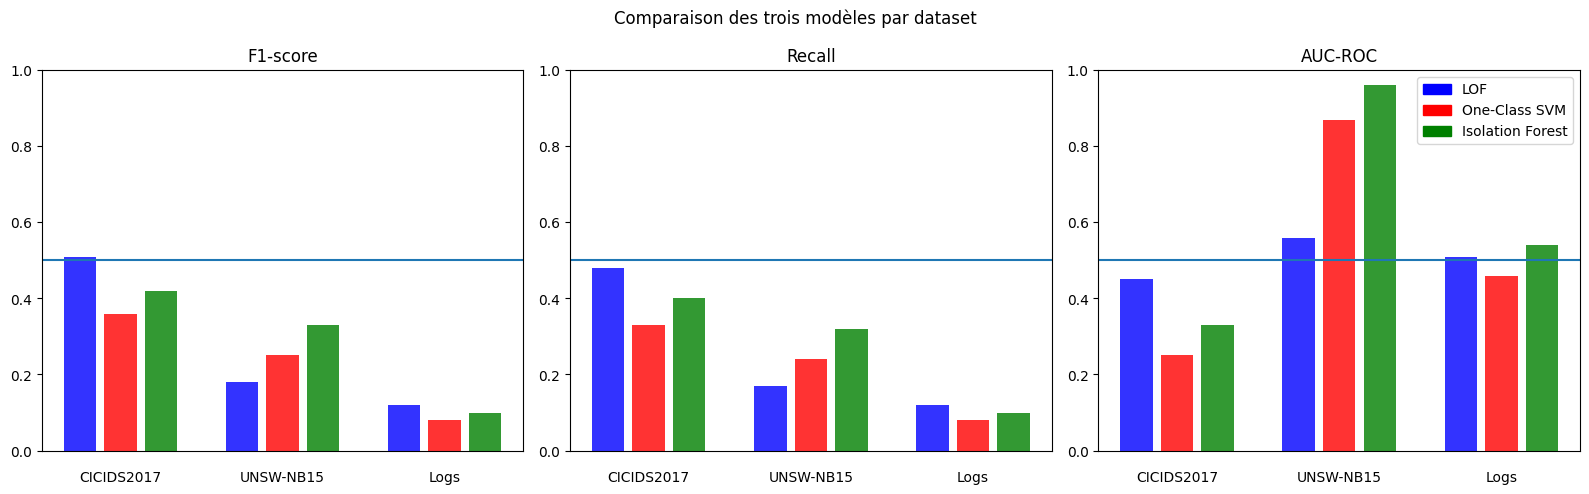

In [36]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metriques = ['F1-score', 'Recall', 'AUC-ROC']
couleurs  = ['blue', 'red', 'green']
datasets  = ['CICIDS2017', 'UNSW-NB15', 'Logs']

for ax, metrique in zip(axes, metriques):
    for i, dataset in enumerate(datasets):
        df_d = df_resultats[df_resultats['Dataset'] == dataset]
        x = np.arange(len(df_d)) + i * 4
        ax.bar(x, df_d[metrique], color=couleurs, alpha=0.8)
        ax.text(x.mean(), -0.08, dataset, ha='center')

    ax.set_title(metrique)
    ax.set_ylim(0, 1)
    ax.set_xticks([])  # supprime les chiffres en abscisse
    ax.axhline(0.5) #score d'un modèle aléatoire 


legendes = [Patch(color=c, label=m) for c, m in zip(couleurs, ['LOF', 'One-Class SVM', 'Isolation Forest'])]
axes[-1].legend(handles=legendes, loc='upper right')

plt.suptitle('Comparaison des trois modèles par dataset')
plt.tight_layout()
plt.show()

Le graphe confirme les conclusions du tableau. Sur le F1-score et le Recall, le 1er dataset CICIDS est le plus haut avec le LOF qui domine, suivi de l'Isolation Forest puis du SVM . Les groupes UNSW et Logs sont nettement plus bas et ont du mal à détecter les anomalies.
Sur l'AUC-ROC c'est l'inverse avec le dataset UNSW qui donne les meilleurs scores avec le SVM (0.87) et surtout l'Isolation Forest (0.96) qui dépasse largement la ligne de référence à 0.5. C'est le seul dataset où les modèles séparent vraiment bien les classes. Sur les dataset CICIDS et Logs, la plupart des barres sont proches ou en dessous de 0.5, ce qui signifie que les modèles ne font pas mieux qu'un tirage aléatoire.
Cela montre que un bon F1 ne signifie pas que le modèle est réellement bon, car les attaques y sont majoritaires. L'AUC-ROC est une métrique plus fiable.


## Courbes ROC

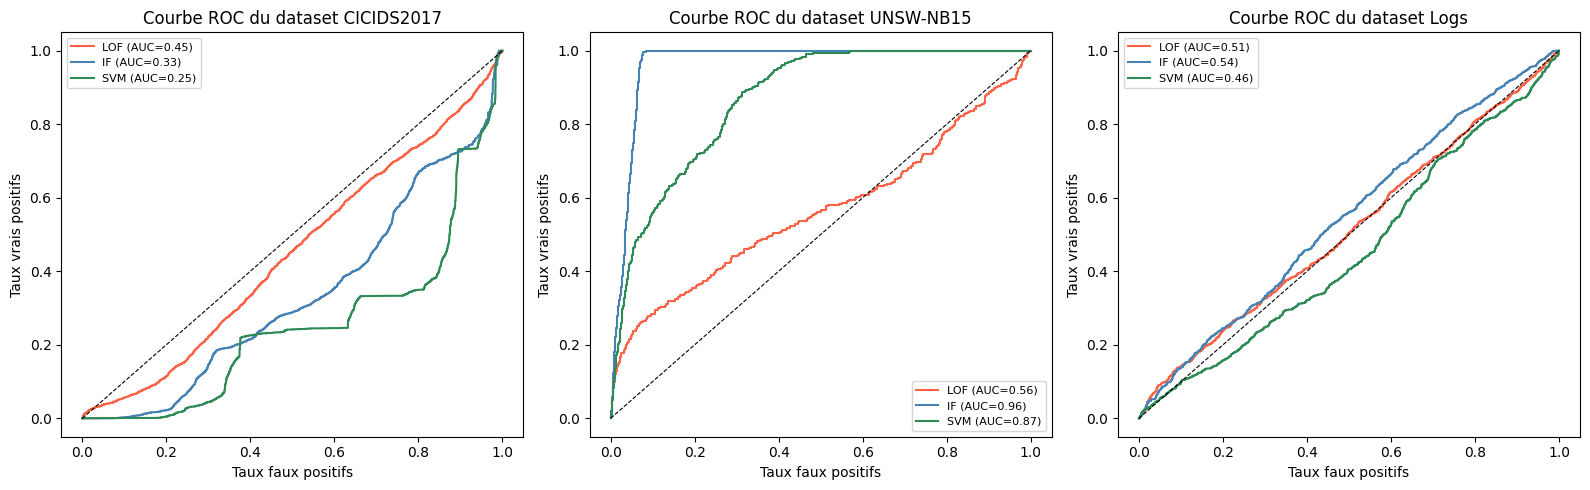

In [38]:
from sklearn.metrics import roc_curve

datasets = [('CICIDS2017', X_cicids_sample, y_cicids_sample, 0.50),('UNSW-NB15',  X_unsw_sample,   y_unsw_sample,   0.03),('Logs',       X_logs_sample,   y_logs_sample,   0.08)]

# modèles et leurs scores associés
def get_modeles(contam):
    return [
        ('LOF', LocalOutlierFactor(n_neighbors=20, contamination=contam),
         lambda m, X: -m.negative_outlier_factor_, 'tomato'),
        ('IF',  IsolationForest(contamination=contam, random_state=42, n_jobs=-1),
         lambda m, X: -m.score_samples(X), 'steelblue'),
        ('SVM', OneClassSVM(kernel='rbf', nu=min(contam, 0.50), gamma='scale'),
         lambda m, X: -m.decision_function(X), 'seagreen')
    ]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nom, X, y, contam) in zip(axes, datasets):
    for label, modele, get_score, couleur in get_modeles(contam):
        modele.fit(X) if hasattr(modele, 'score_samples') else modele.fit_predict(X)
        score = get_score(modele, X)
        fpr, tpr, _ = roc_curve(y, score)
        ax.plot(fpr, tpr, label=f'{label} (AUC={roc_auc_score(y, score):.2f})', color=couleur)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # ligne aléatoire
    ax.set(title=f'Courbe ROC du dataset {nom}', xlabel='Taux faux positifs', ylabel='Taux vrais positifs')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Les courbes ROC confirment les conclusions du tableau.Sur CICIDS2017, les trois courbes sont proches ou en dessous de la diagonale pointillée qui représente un modèle aléatoire avec des AUC de 0.45, 0.33 et 0.25. Cela signifie que malgré un f1 correct vu précédemment, aucun modèle ne sépare vraiment les classes mais le LOF est le moins mauvais mais reste sous 0.5. Sur UNSW-NB15 l'Isolation Forest avec un AUC de 0.96 monte très rapidement vers le coin supérieur gauche et est le signe d'une excellente séparation. Le SVM se comporte aussi très bien mais en revanche le LOF est à peine au-dessus de la diagonaleco nfirmant qu'il est inadapté à ce dataset.
Sur Logs, les trois courbes suivent quasiment la diagonale avec des AUC entre 0.46 et 0.54 donc aucun modèle ne fait mieux qu'un tirage aléatoire. 



## Identification du meilleur baseline

In [41]:
print("Meilleur modèle par dataset (f1-score) ")
for dataset in ['CICIDS2017', 'UNSW-NB15', 'Logs']:
    df_d = df_resultats[df_resultats['Dataset'] == dataset]
    meilleur = df_d.loc[df_d['F1-score'].idxmax()]
    print(f"{dataset:12} : {meilleur['Modèle']:20} avec f1={meilleur['F1-score']} , AUC={meilleur['AUC-ROC']} et temps={meilleur['Temps (s)']}s")

print("\n Meilleur modèle global (f1 moyen sur les 3 datasets) ")
f1_moyen = df_resultats.groupby('Modèle')['F1-score'].mean().sort_values(ascending=False)
print(f1_moyen)

Meilleur modèle par dataset (f1-score) 
CICIDS2017   : LOF                  avec f1=0.51 , AUC=0.45 et temps=0.77s
UNSW-NB15    : Isolation Forest     avec f1=0.33 , AUC=0.96 et temps=0.94s
Logs         : LOF                  avec f1=0.12 , AUC=0.51 et temps=0.19s

 Meilleur modèle global (f1 moyen sur les 3 datasets) 
Modèle
Isolation Forest    0.283333
LOF                 0.270000
One-Class SVM       0.230000
Name: F1-score, dtype: float64


Les résultats confirment qu'il n'existe pas de modèle universel en effet le meilleur dépend du dataset. Sur CICIDS2017, le LOF gagne avec un f1 de 0.51 mais son AUC de 0.45 reste sous la ligne aléatoire. Sur UNSW-NB15, l'Isolation Forest s'impose clairement avec un f1 de 0.33 et surtout un AUC de 0.96, c'est le seul résultat vraiment fiable de toute la comparaison. Sur Logs, le LOF gagne avec un f1 de 0.12 mais tous les modèles échouent sur ce dataset.
En global, l'Isolation Forest obtient le meilleur f1 moyen (0.28) devant le LOF (0.27) et le SVM (0.23). L'écart entre les trois est faible, mais par sa vitesse et son bon AUC sur le dataset UNSW, l'Isolation Forest s'impose comme le meilleur baseline.

## Bilan

En calculant des métriques complémentaires la précision (rappel, F1-score et AUC-ROC ) on obtient une vision bien plus complète que les simples matrices de confusion des notebooks précédents. On remarque que l'algorithme Isolation Forest est le meilleur baseline global avec un f1 moyen de 0.28 et une AUC exceptionnelle de 0.96 sur UNSW-NB15. Il est aussi systématiquement plus rapide que le One-Class SVM qui n'a jamais les meilleures performances malgré des temps d'entraînement bien plus rapide.
Le LOF peut être préféré sur des datasets où les attaques sont massives et groupées comme CICIDS2017, mais son instabilité sur les autres datasets le rend moins fiable en pratique. Puis les trois algorithmes échouent sur le dataset Logs avec des AUC proches de 0.5, ce qui confirme que le problème vient des données et non des modèles.